In [2]:
from mdpocketclustering.registry import SimulationRegistry
from mdpocketclustering.systems import SystemDefinition, SimulationRun, SimulationFiles, Mutation
from mdpocketclustering.analysis import aggregate_replicates
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# 1. create fake simulations
# --------------------------------------------------

def make_run(mut, rep, energy):
    system = SystemDefinition(
        system_id="TEST",
        protein_name="EGFR",
        mutations=[
            Mutation(chain="A", resid=525, wildtype="R", mutant=mut)
        ],
        components=[]
    )

    run = SimulationRun(
        run_id=f"{mut}_{rep}",
        system=system,
        replicate=rep,
        files=SimulationFiles("test", "test")
    )

    run.binding_energy = energy
    return run


registry = SimulationRegistry()

registry.extend([
    make_run("WT", 1, -10),
    make_run("WT", 2, -20),
    make_run("WT", 3, -15),

    make_run("MUT", 1, -40),
    make_run("MUT", 2, -50),
    make_run("MUT", 3, -45),
    
    make_run("R525H", 1, -40),
    make_run("R525H", 2, -60),
    make_run("R525H", 3, -45),
])

      mutation       mean       std  count
0    A:R525MUT -45.000000   5.00000      3
1  A:R525R525H -48.333333  10.40833      3
2     A:R525WT -15.000000   5.00000      3


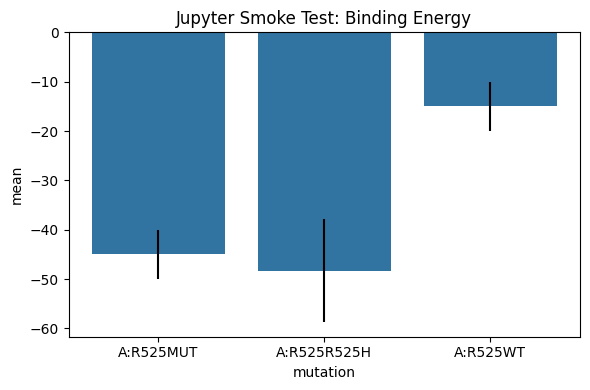

In [3]:
# --------------------------------------------------
# 2. aggregate
# --------------------------------------------------

df = aggregate_replicates(
    registry,
    value="binding_energy",
    by=["mutation"]
)

print(df)


# --------------------------------------------------
# 3. plot
# --------------------------------------------------

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="mutation",
    y="mean"
)

plt.errorbar(
    x=range(len(df)),
    y=df["mean"],
    yerr=df["std"],
    fmt="none",
    c="black"
)

plt.title("Jupyter Smoke Test: Binding Energy")
plt.tight_layout()
plt.show()